In [187]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import gaussian_kde
from models import CondSM
from utils import f_sm, sample_X, mse_loss_normalized, normalize_over_range
import matplotlib.ticker as mtick

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
print('Libraries loaded')

data_type = 'grad_away_1e7'
state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cuda')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

cuda
Libraries loaded


<All keys matched successfully>

In [200]:
input_index_0 = 2
input_index_1 = 4

num_voltages = 7

e_0 = 1.60217663e-19
time_scale = 1e21
out_scale = e_0 * time_scale

control_indices = [c_index for c_index in range(num_voltages) if c_index not in (input_index_0,input_index_1)]
c_v_min = -1.
c_v_max = 1.
model = model.to(device)
with torch.no_grad():
    x = torch.zeros(4096, num_voltages, device=device)
    x.uniform_(c_v_min, c_v_max)     # or whatever voltage range you use
    y = model(x).squeeze()
    S_std = y.std().item()
    S_med = y.abs().median().item()
print("std:", S_std, "median|y|:", S_med)

#print(control_indices)
# XOR
on_volt = 0.5
gate_inputs = [
    [0.0, 0.0],
    [0.0, on_volt],
    [on_volt, 0.0],
    [on_volt, on_volt]
]

gate = 'NAND'

if gate == 'XOR':
    truth_outputs = [
        0.,
        1.,
        1.,
        0.
    ]

elif gate == 'AND':
    truth_outputs = [
        0.,
        0.,
        0.,
        1.
    ]

elif gate == 'OR':
    truth_outputs = [
        0.,
        1.,
        1.,
        1.
    ]

elif gate == 'NOR':
    truth_outputs = [
        1.,
        0.,
        0.,
        0.
    ]

elif gate == 'NAND':
    truth_outputs = [
        1.,
        1.,
        1.,
        0.
    ]

import numpy as np
import matplotlib.pyplot as plt

def plot_gate_from_currents(gate_inputs, currents, currents_sem=None, sim_currents=None, sim_sem=None):
    y = np.asarray(currents, dtype=float).reshape(-1)
    if len(y) != len(gate_inputs):
        raise ValueError("`currents` length must match gate_inputs length.")

    if currents_sem is not None:
        sem = np.asarray(currents_sem, dtype=float).reshape(-1)
        if len(sem) != len(gate_inputs):
            raise ValueError("`currents_sem` length must match gate_inputs length.")
    else:
        sem = None

    if sim_currents is not None:
        y_sim = np.asarray(sim_currents, dtype=float).reshape(-1)
        if len(y_sim) != len(gate_inputs):
            raise ValueError("`sim_currents` length must match gate_inputs length.")
    else:
        y_sim = None

    if sim_sem is not None:
        sim_sem = 1.96*np.asarray(sim_sem, dtype=float).reshape(-1)
        if len(sim_sem) != len(gate_inputs):
            raise ValueError("`sim_sem` length must match gate_inputs length.")
    else:
        sim_sem = None

    in_0 = [gi[0] for gi in gate_inputs]
    in_1 = [gi[1] for gi in gate_inputs]

    fig, axes = plt.subplots(3, 1, figsize=(6, 4), sharex=True)
    fig.subplots_adjust(left=0.22, right=0.98, bottom=0.12, top=0.98, hspace=0.15)

    labels = ["$V_0$", "$V_1$", "$I_{\\mathrm{out}} \\quad [nA]$"]
    t = np.arange(len(gate_inputs) + 1)  # 0..4

    def style_axis(ax, label):
        ax.set_ylabel(label, rotation=90.0)
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    # ---- output (mean step) ----
    y_out = np.r_[y, y[-1]]
    axes[2].step(t, y_out, where="post", lw=1, label="ground truth")

    # ---- shaded SEM band (mean ± sem) ----
    if sem is not None:
        lo = np.r_[y - sem, (y - sem)[-1]]
        hi = np.r_[y + sem, (y + sem)[-1]]
        axes[2].fill_between(t, lo, hi, step="post", alpha=0.25)

    # optional overlay: simulated
    if y_sim is not None:
        y_sim_out = np.r_[y_sim, y_sim[-1]]
        axes[2].step(t, y_sim_out, where="post", lw=2, ls="--", label="simulated")

        if sim_sem is not None:
            lo_s = np.r_[y_sim - sim_sem, (y_sim - sim_sem)[-1]]
            hi_s = np.r_[y_sim + sim_sem, (y_sim + sim_sem)[-1]]
            axes[2].fill_between(t, lo_s, hi_s, step="post", alpha=0.15)

        axes[2].legend(frameon=False, loc="best")

    style_axis(axes[2], labels[2])

    # ---- inputs ----
    y0 = np.r_[in_0, in_0[-1]]
    axes[0].step(t, y0, where="post", lw=2, c='r')
    style_axis(axes[0], labels[0])

    y1 = np.r_[in_1, in_1[-1]]
    axes[1].step(t, y1, where="post", lw=2, c='g')
    style_axis(axes[1], labels[1])

    centers = np.arange(len(gate_inputs)) + 0.5
    state_labels = ["00", "01", "10", "11"][:len(gate_inputs)]
    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(state_labels)
    axes[-1].set_xlabel("Input $V_0, V_1 \\quad [V]$")

    return axes


"""def plot_gate_from_currents(gate_inputs, currents, sim_currents=None):

    y = np.asarray(currents, dtype=float).reshape(-1)
    if len(y) != len(gate_inputs):
        raise ValueError(f"`currents` length ({len(y)}) must match gate_inputs length ({len(gate_inputs)}).")

    if sim_currents is not None:
        y_sim = np.asarray(sim_currents, dtype=float).reshape(-1)
        if len(y_sim) != len(gate_inputs):
            raise ValueError(f"`sim_currents` length ({len(y_sim)}) must match gate_inputs length ({len(gate_inputs)}).")
    else:
        y_sim = None

    in_0 = [gi[0] for gi in gate_inputs]
    in_1 = [gi[1] for gi in gate_inputs]

    fig, axes = plt.subplots(3, 1, figsize=(6, 4), sharex=True)
    fig.subplots_adjust(left=0.22, right=0.98, bottom=0.12, top=0.98, hspace=0.15)

    labels = ["$V_0$", "$V_1$", "$I_{\\mathrm{out}} \\quad [nA]$"]

    # time axis: 4 states -> 5 edges
    t = np.arange(len(gate_inputs) + 1)

    def style_axis(ax, label):
        ax.set_ylabel(label, rotation=90.0)
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

    # output (ground truth)
    y_out = np.r_[y, y[-1]]
    axes[2].step(t, y_out, where="post", lw=2, label="ground truth")
    style_axis(axes[2], labels[2])

    # optional overlay: simulated currents
    if y_sim is not None:
        y_sim_out = np.r_[y_sim, y_sim[-1]]
        axes[2].step(t, y_sim_out, where="post", lw=2, ls="--", label="simulated")
        axes[2].legend(frameon=False, loc="best")

    # input 0
    y0 = np.r_[in_0, in_0[-1]]
    axes[0].step(t, y0, where="post", lw=2, c='r')
    style_axis(axes[0], labels[0])

    # input 1
    y1 = np.r_[in_1, in_1[-1]]
    axes[1].step(t, y1, where="post", lw=2, c='g')
    style_axis(axes[1], labels[1])

    # x-ticks at the middle of each interval, labeled by input combination
    centers = np.arange(len(gate_inputs)) + 0.5
    state_labels = ["00", "01", "10", "11"][:len(gate_inputs)]
    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(state_labels)
    axes[-1].set_xlabel("Input $V_0, V_1 \\quad [V]$")

    # margins
    for ax in axes:
        ymin, ymax = ax.get_ylim()
        margin = 0.1 * (ymax - ymin if ymax > ymin else 1.0)
        ax.set_ylim(ymin - margin, ymax + margin)
        #ax.set_box_aspect(1)

    return axes"""

def plot_gate(model, theta, control_indices, gate_inputs):

    input_tensor = torch.zeros(len(gate_inputs), num_voltages)
    control_voltages = torch.from_numpy(theta).float().expand(len(gate_inputs), -1)
    for j, c_idx in enumerate(control_indices):
        input_tensor[:, c_idx] = control_voltages[:, j]
    
    for k in range(len(gate_inputs)):
        input_tensor[k, input_index_0] = gate_inputs[k][0]
        input_tensor[k, input_index_1] = gate_inputs[k][1]
    input_tensor = input_tensor.to(device)

    model.eval()
    with torch.no_grad():
        y = (model(input_tensor).detach().cpu().squeeze().numpy()).tolist()
    #print(y)
    in_0 = [gate_inputs[0][0], gate_inputs[1][0], gate_inputs[2][0], gate_inputs[3][0]]
    in_1 = [gate_inputs[0][1], gate_inputs[1][1], gate_inputs[2][1], gate_inputs[3][1]]
    
    fig, axes = plt.subplots(3, 1, figsize=(6, 4), sharex=True)
    fig.subplots_adjust(left=0.22, right=0.98, bottom=0.12, top=0.98, hspace=0.15)

    labels = ["$V_0$", "$V_1$", "$I_{\mathrm{out}} \quad [nA]$"]
    
    # time axis: 4 states -> 5 edges
    t = np.arange(len(in_0) + 1)
    
    # helper: nice common style
    def style_axis(ax, label):
        ax.set_ylabel(label, rotation=90.0)#, ha="right", va="center")
        ax.grid(alpha=0.3)
        ax.set_facecolor("whitesmoke")
        # remove top/right spines
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
    
    # output
    y_out = np.r_[y, y[-1]]
    axes[2].step(t, y_out, where="post", lw=2)
    style_axis(axes[2], labels[2])
    
    # input 0
    y0 = np.r_[in_0, in_0[-1]]
    axes[0].step(t, y0, where="post", lw=2, c='r')
    style_axis(axes[0], labels[0])
    
    # input 1
    y1 = np.r_[in_1, in_1[-1]]
    axes[1].step(t, y1, where="post", lw=2, c='g')
    style_axis(axes[1], labels[1])
    
    # x-ticks at the middle of each interval, labeled by input combination
    centers = np.arange(len(y)) + 0.5
    state_labels = ["00", "01", "10", "11"]
    axes[-1].set_xticks(centers)
    axes[-1].set_xticklabels(state_labels)
    axes[-1].set_xlabel("Input $V_0, V_1 \quad [V]$")
    
    # small margins so steps aren't glued to edges
    for ax in axes:
        ymin, ymax = ax.get_ylim()
        margin = 0.1 * (ymax - ymin if ymax > ymin else 1.0)
        ax.set_ylim(ymin - margin, ymax + margin)
        #ax.set_box_aspect(1)
    
    return axes

print('DONE')
print(gate)

std: 4.282244682312012 median|y|: 4.157057285308838
DONE
NAND


In [201]:
import numpy as np
import torch

# ----------------------------
# User settings / assumptions
# ----------------------------
seed = 42
torch.manual_seed(seed)

# gate_inputs assumed ordered as: [00, 01, 10, 11]
# gate_inputs = [[0,0],[0,on],[on,0],[on,on]]
# truth_outputs length must be 4 with values 0.0/1.0 in the SAME order.
assert len(gate_inputs) == 4
assert len(truth_outputs) == 4
assert all(v in (0.0, 1.0) for v in truth_outputs)

# Build indices for any gate from truth table
HIGH_IDX = torch.tensor([i for i, v in enumerate(truth_outputs) if v == 1.0],
                        device=device, dtype=torch.long)
LOW_IDX  = torch.tensor([i for i, v in enumerate(truth_outputs) if v == 0.0],
                        device=device, dtype=torch.long)

if HIGH_IDX.numel() == 0 or LOW_IDX.numel() == 0:
    raise ValueError("truth_outputs must contain at least one 1.0 and one 0.0.")

# Targets for log-prob method (gate-agnostic)
t = torch.tensor(truth_outputs, device=device, dtype=torch.float32).unsqueeze(0)  # [1,4]

# ----------------------------
# Sampling
# ----------------------------
num_samples = 10_000_000
theta_samples = torch.rand(size=(num_samples, 5), device=device) * (c_v_max - c_v_min) + c_v_min

# ----------------------------
# Noise (same units as model output current)
# sigma = sigma_val * S_std
# ----------------------------
sigma_val = 0.01
sigma = float((sigma_val * S_std).item() if torch.is_tensor(S_std) else sigma_val * S_std)

chunk_size = 1024
scores = np.empty(num_samples, dtype=np.float32)

model = model.to(device)
model.eval()

# ----------------------------
# Scoring choices
# ----------------------------
# 1) Pure sigma-margin (separability only)
USE_SIGMA_MARGIN = False

# 2) Sigma-margin + "digital level" compactness penalty (recommended)
USE_MARGIN_COMPACTNESS = True

# 3) Analytic log-probability of correct classification under Gaussian noise
USE_LOGPROB = False

# Compactness strength: larger => forces HIGHs and LOWs to be more equal
# Good starting range: 0.1–0.5
alpha = 1.0

# If your device is inverted (logic-1 is LOWER current), set INVERT=True
INVERT = False

eps = 1e-12

with torch.no_grad():
    for start in range(0, num_samples, chunk_size):
        end = min(start + chunk_size, num_samples)
        B = end - start

        theta_b = theta_samples[start:end].to(dtype=torch.float32)

        # Build input tensor: [B,4,num_voltages]
        input_b = torch.zeros((B, len(gate_inputs), num_voltages),
                              device=device, dtype=torch.float32)

        # Fill control voltages
        for j, c_idx in enumerate(control_indices):
            input_b[:, :, c_idx] = theta_b[:, j].unsqueeze(1)  # [B,1] -> broadcast over 4

        # Fill gate input voltages
        gate_in = torch.tensor(gate_inputs, device=device, dtype=torch.float32)  # [4,2]
        input_b[:, :, input_index_0] = gate_in[:, 0].unsqueeze(0)  # [1,4]
        input_b[:, :, input_index_1] = gate_in[:, 1].unsqueeze(0)  # [1,4]

        # Forward: [B*4,num_voltages] -> [B,4]
        y0 = model(input_b.reshape(B * 4, num_voltages)).squeeze().reshape(B, 4)

        # Select currents for classes
        I_high = y0.index_select(dim=1, index=HIGH_IDX)  # [B, nH]
        I_low  = y0.index_select(dim=1, index=LOW_IDX)   # [B, nL]

        # Worst-case separation
        min_high = I_high.min(dim=1).values  # [B]
        max_high = I_high.max(dim=1).values  # [B]
        min_low  = I_low.min(dim=1).values   # [B]
        max_low  = I_low.max(dim=1).values   # [B]

        # margin > 0 means separable by one threshold (noise-free)
        margin = min_high - max_low  # [B]

        if INVERT:
            # If logic-1 is LOWER current, separability means LOW class above HIGH class.
            # Equivalent: swap roles by flipping margin sign.
            margin = -margin

        if USE_SIGMA_MARGIN:
            robust = margin / (sigma + 1e-30)

        elif USE_MARGIN_COMPACTNESS:
            # Compactness penalties (ranges within HIGH and LOW sets)
            range_high = max_high - min_high  # [B]
            range_low  = max_low - min_low    # [B]

            # Combined score in "sigmas"
            robust = (margin - alpha * (range_high + range_low)) / (sigma + 1e-30)

        elif USE_LOGPROB:
            # Choose threshold halfway between worst LOW and worst HIGH
            # (still gate-agnostic because HIGH/LOW come from truth_outputs)
            T = 0.5 * (min_high + max_low)  # [B]
            if INVERT:
                # If inverted, best threshold is still between, but "correct side" flips.
                # We'll handle flip by swapping t -> 1-t.
                t_eff = 1.0 - t
            else:
                t_eff = t

            z = (T.unsqueeze(1) - y0) / (sigma + 1e-30)  # [B,4]
            Phi = torch.special.ndtr(z)                  # [B,4]

            # If target is 1: P(correct)=P(I+e > T)=1-Phi
            # If target is 0: P(correct)=P(I+e <=T)=Phi
            P_correct = torch.where(t_eff > 0.5, 1.0 - Phi, Phi).clamp_min(eps)
            robust = torch.log(P_correct).mean(dim=1)  # [B]

        else:
            raise ValueError("Pick one scoring mode: USE_SIGMA_MARGIN / USE_MARGIN_COMPACTNESS / USE_LOGPROB")

        scores[start:end] = robust.detach().cpu().numpy().astype(np.float32)

print("Done. scores shape:", scores.shape)

best_idx = int(np.argmax(scores))
best_theta = theta_samples[best_idx].detach().cpu()
best_score = float(scores[best_idx])
print("Best idx:", best_idx, "best_score:", best_score)
print("Best theta:", best_theta.tolist())

# Optional: inspect best currents to verify logic levels
# with torch.no_grad():
#     # Build [4,num_voltages] input for best_theta
#     inp = torch.zeros((4, num_voltages), device=device, dtype=torch.float32)
#     for j, c_idx in enumerate(control_indices):
#         inp[:, c_idx] = best_theta[j].to(device=device)
#     inp[:, input_index_0] = gate_in[:, 0]
#     inp[:, input_index_1] = gate_in[:, 1]
#     y_best = model(inp).squeeze().detach().cpu().numpy()
# print("Best currents (00,01,10,11):", y_best)

# Save (optional)
np.savetxt(
     f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data_alpha={alpha}/'
     f'{data_type}_{gate}_params_seed={seed}_sigma_val={sigma_val}_alpha={alpha}_.txt',
     best_theta.tolist()
)
print(gate)
print("alpha:", alpha)
print("sigma_val:", sigma_val)

Done. scores shape: (10000000,)
Best idx: 208303 best_score: 3.3000993728637695
Best theta: [-0.580814003944397, -0.4918575882911682, 0.9401954412460327, -0.5909789204597473, -0.1995633840560913]
NAND
alpha: 1.0
sigma_val: 0.01


NAND


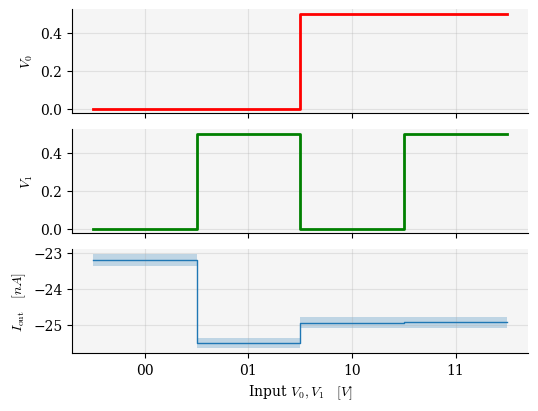

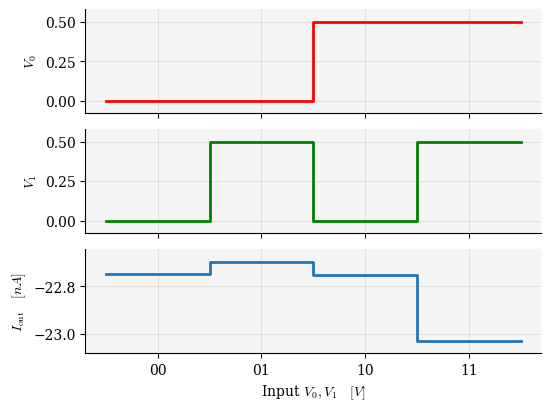

In [168]:
C = 1.602e-19
scale = 1e21

I_00 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_0.0_0.0_new_1.npz')['current'] * scale
I_01 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_0.0_{on_volt}_new_1.npz')['current'] * scale
I_10 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_{on_volt}_0.0_new_1.npz')['current'] * scale
I_11 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_{on_volt}_{on_volt}_new_1.npz')['current'] * scale

I_00_sem = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_0.0_0.0_new_1.npz')['sem'] * scale
I_01_sem = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_0.0_{on_volt}_new_1.npz')['sem'] * scale
I_10_sem = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_{on_volt}_0.0_new_1.npz')['sem'] * scale
I_11_sem = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_{on_volt}_{on_volt}_new_1.npz')['sem'] * scale

true_Is = [I_00, I_01, I_10, I_11]
true_Is_sem = [I_00_sem, I_01_sem, I_10_sem, I_11_sem]
plot_gate_from_currents(gate_inputs, true_Is, true_Is_sem)

plot_gate(model, best_theta.numpy(), control_indices, gate_inputs)
print(gate)

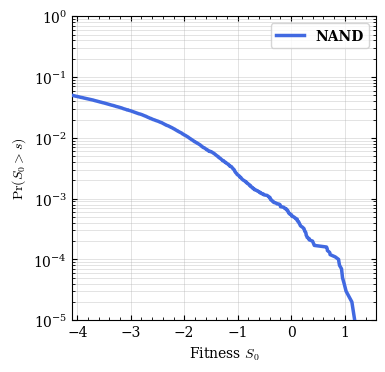

In [202]:
s = np.asarray(scores[:100_000], float)
s = s[np.isfinite(s)]
s_sorted = np.sort(s)
n = len(s_sorted)

ecdf = np.arange(1, n+1) / n
ccdf = 1 - ecdf  # P(S0 > s) approximately

fig, ax = plt.subplots(figsize=(4,4))
ax.set_position([0.18, 0.12, 0.76, 0.83])
ax.minorticks_on()
ax.tick_params(top=True, right=True, which='both')
ax.tick_params(which='both', direction='in')

ax.plot(s_sorted, ccdf, lw=2.5, zorder=6, c='royalblue')
ax.set_yscale('log')
#ax.set_xscale('log')
x_lo, x_hi = np.quantile(s_sorted, 0.95), np.quantile(s_sorted, 1.0)
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(1/n, 1)  # avoid 0 on log scale

ax.grid(lw=0.5, alpha=0.5, which='major')
ax.grid(lw=0.5, alpha=0.5, which='minor', axis='y')
ax.set_xlabel(r'Fitness $S_0$')
#ax.set_ylabel(r'$1-\mathrm{ECDF}(S_0)$')
ax.set_ylabel(r'$\Pr(S_0 > s)$')

#ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))  # 0.2 -> "20%"
ax.set_box_aspect(1)
ax.legend(labels=[rf'{gate}'], prop={'weight': 'bold'})
fig.savefig(f'ccdf_alpha={alpha}_gate={gate}_{data_type}_seed={seed}_sigm_val={sigma_val}.pdf', bbox_inches=None, pad_inches=None)